# Performance das Datas Duplas — Home Electronics (1P vs 3P)

Este notebook compara a performance da última data dupla (**8/8**, sábado) com as
datas duplas anteriores do ano (**7/7, 6/6, 5/5, 4/4, 3/3, 2/2, 1/1**), com quebra:

- por **categoria agg1** dentro da vertical *Home Electronics*
- por **canal**: 1P (venda própria) vs 3P (marketplace/sellers)

Métricas: **GMV**, **Unidades vendidas** e **Market Share**.

> **Como usar este notebook**
> 1. Preencha as constantes na célula *Configuração* com o projeto/dataset/tabelas reais do BigQuery.
> 2. Ajuste as queries em `build_sales_query` / `build_market_query` para o esquema real das suas tabelas.
> 3. Mude `USE_SAMPLE_DATA = False` para rodar contra o BigQuery.
>
> Por padrão (`USE_SAMPLE_DATA = True`) o notebook roda de ponta a ponta com **dados sintéticos**,
> só para validar toda a estrutura de análise e os gráficos antes de plugar os dados reais.

**Dependências:** `pip install pandas numpy matplotlib google-cloud-bigquery db-dtypes`


In [1]:
import numpy as np
import pandas as pd
from datetime import date

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


## 1. Configuração

In [2]:
# ── CONFIGURAÇÃO ──────────────────────────────────────────────────────
# TODO: preencha com os identificadores reais do seu ambiente BigQuery.
PROJECT_ID   = "SEU_PROJECT_ID"              # ex.: "meli-bi-data-prod"
SALES_TABLE  = "SEU_DATASET.fact_sales"      # tabela de vendas, grão pedido/item
MARKET_TABLE = "SEU_DATASET.market_gmv"      # GMV total de mercado, para market share (opcional)

# Vertical de interesse dentro da hierarquia agg1
AGG1_VERTICAL = "Home Electronics"

# Datas duplas a comparar — a mais recente (8/8) primeiro.
# Ajuste o ano/lista conforme o calendário promocional real.
DOUBLE_DATES = [
    ("8/8", date(2026, 8, 8)),
    ("7/7", date(2026, 7, 7)),
    ("6/6", date(2026, 6, 6)),
    ("5/5", date(2026, 5, 5)),
    ("4/4", date(2026, 4, 4)),
    ("3/3", date(2026, 3, 3)),
    ("2/2", date(2026, 2, 2)),
    ("1/1", date(2026, 1, 1)),
]

# Ordem cronológica (mais antiga → mais recente), usada nos eixos dos gráficos
CHRONO_ORDER = [label for label, _ in DOUBLE_DATES][::-1]

# True  = usa dados sintéticos (não requer acesso ao BigQuery) — útil para validar o notebook
# False = executa as queries reais definidas na seção 2
USE_SAMPLE_DATA = True


## 2. Extração dos dados (BigQuery)

Ajuste os nomes de colunas/tabelas conforme o schema real. O grão esperado após
o `GROUP BY` é **data dupla × categoria agg1 × canal**.

In [3]:
def build_sales_query(target_date):
    """GMV e unidades por categoria agg1 e canal, para uma data dupla."""
    return f"""
    SELECT
      DATE(order_created_at)   AS order_date,
      agg1_category            AS agg1_category,   -- categoria dentro da vertical
      channel                  AS channel,          -- '1P' ou '3P'
      SUM(gmv_local)            AS gmv,
      SUM(units)                AS units
    FROM `{PROJECT_ID}.{SALES_TABLE}`
    WHERE DATE(order_created_at) = DATE('{target_date.isoformat()}')
      AND agg1_vertical = '{AGG1_VERTICAL}'
    GROUP BY 1, 2, 3
    """


def build_market_query(target_date):
    """GMV total de mercado por categoria agg1, para cálculo de market share."""
    return f"""
    SELECT
      DATE(ref_date)     AS order_date,
      agg1_category       AS agg1_category,
      SUM(market_gmv)      AS market_gmv
    FROM `{PROJECT_ID}.{MARKET_TABLE}`
    WHERE DATE(ref_date) = DATE('{target_date.isoformat()}')
      AND agg1_vertical = '{AGG1_VERTICAL}'
    GROUP BY 1, 2
    """


def run_bigquery(sql):
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT_ID)
    return client.query(sql).to_dataframe()


## 3. Dados sintéticos (modo demo, sem BigQuery)

In [4]:
def generate_sample_data(seed=42):
    """Dados sintéticos com o mesmo schema esperado da extração real,
    só para validar a estrutura do notebook antes de plugar o BigQuery."""
    rng = np.random.default_rng(seed)
    categories = ["TVs", "Áudio e Som", "Linha Branca", "Pequenos Eletrodomésticos", "Climatização"]
    channels = ["1P", "3P"]
    cat_weight = {"TVs": 1.4, "Áudio e Som": 0.8, "Linha Branca": 1.1,
                  "Pequenos Eletrodomésticos": 0.9, "Climatização": 0.7}

    # crescimento orgânico leve ao longo do ano + pico sazonal na própria 8/8
    growth_by_label = {label: 1 + 0.05 * i for i, label in enumerate(CHRONO_ORDER)}
    seasonal_boost = {"8/8": 1.35, "6/6": 1.12}

    rows = []
    for label, d in DOUBLE_DATES:
        boost = seasonal_boost.get(label, 1.0)
        for cat in categories:
            for ch in channels:
                ch_weight = 1.2 if ch == "1P" else 1.0
                noise = rng.normal(1.0, 0.05)
                gmv = 500_000 * cat_weight[cat] * ch_weight * growth_by_label[label] * boost * noise
                units = gmv / rng.normal(650, 40)
                market_gmv = gmv / rng.uniform(0.28, 0.42)  # nosso share fica entre ~28% e 42%
                rows.append(dict(date_label=label, order_date=d, agg1_category=cat,
                                  channel=ch, gmv=gmv, units=units, market_gmv=market_gmv))
    return pd.DataFrame(rows)


## 4. Carregamento dos dados

In [5]:
def load_data():
    if USE_SAMPLE_DATA:
        return generate_sample_data()

    frames = []
    for label, d in DOUBLE_DATES:
        sales_df = run_bigquery(build_sales_query(d))
        market_df = run_bigquery(build_market_query(d))
        merged = sales_df.merge(market_df, on=["order_date", "agg1_category"], how="left")
        merged["date_label"] = label
        frames.append(merged)
    return pd.concat(frames, ignore_index=True)


df = load_data()
df["date_label"] = pd.Categorical(df["date_label"], categories=CHRONO_ORDER, ordered=True)
df.head()


,date_label,order_date,agg1_category,channel,gmv,units,market_gmv
0,8/8,2026-08-08,TVs,1P,"1,554,224.57","2,554.61","3,883,583.62"
1,8/8,2026-08-08,TVs,3P,"1,335,746.27","2,335.39","3,206,403.12"
2,8/8,2026-08-08,Áudio e Som,1P,"880,391.74","1,381.33","2,954,970.23"
3,8/8,2026-08-08,Áudio e Som,3P,"697,906.55","1,018.58","1,703,261.72"
4,8/8,2026-08-08,Linha Branca,1P,"1,206,821.25","1,736.21","3,527,912.62"


## 5. Agregações

In [6]:
overall = (df.groupby("date_label", observed=True)
             .agg(gmv=("gmv", "sum"), units=("units", "sum"), market_gmv=("market_gmv", "sum"))
             .reindex(CHRONO_ORDER))
overall["market_share"] = overall["gmv"] / overall["market_gmv"]
overall["gmv_growth"] = overall["gmv"].pct_change()
overall["units_growth"] = overall["units"].pct_change()

by_channel = (df.groupby(["date_label", "channel"], observed=True)
                .agg(gmv=("gmv", "sum"), units=("units", "sum"))
                .reset_index())
by_channel_gmv = by_channel.pivot(index="date_label", columns="channel", values="gmv").reindex(CHRONO_ORDER)

by_category = (df.groupby(["date_label", "agg1_category"], observed=True)
                 .agg(gmv=("gmv", "sum"), units=("units", "sum"), market_gmv=("market_gmv", "sum"))
                 .reset_index())
by_category["market_share"] = by_category["gmv"] / by_category["market_gmv"]
cat_gmv_pivot = by_category.pivot(index="date_label", columns="agg1_category", values="gmv").reindex(CHRONO_ORDER)

by_channel_category = (df.groupby(["date_label", "agg1_category", "channel"], observed=True)
                          .agg(gmv=("gmv", "sum"), units=("units", "sum"))
                          .reset_index())

overall


,gmv,units,market_gmv,market_share,gmv_growth,units_growth
date_label,,,,,,
1/1,"5,375,085.71","8,411.62","15,936,425.21",0.34,NaN,NaN
2/2,"5,764,824.56","8,957.94","17,954,060.62",0.32,0.07,0.06
3/3,"5,918,166.39","9,182.01","17,339,654.77",0.34,0.03,0.03
4/4,"6,282,251.02","9,825.01","18,935,406.09",0.33,0.06,0.07
5/5,"6,321,416.57","9,820.41","17,957,386.58",0.35,0.01,-0.00
6/6,"7,425,197.58","11,315.77","21,993,950.31",0.34,0.17,0.15
7/7,"7,036,572.06","10,788.16","21,109,909.27",0.33,-0.05,-0.05
8/8,"9,852,564.90","15,340.62","27,111,079.28",0.36,0.40,0.42


## 6. Estilo dos gráficos

Paleta e tokens seguem o design system de referência: cor categórica em ordem fixa
(1P = azul, 3P = laranja), tinta secundária para rótulos/valores, grid discreto.

In [7]:
import matplotlib.pyplot as plt

COLOR_1P = "#2a78d6"
COLOR_3P = "#eb6834"
CAT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
TEXT_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "grid.color": GRIDLINE,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})


def brl_millions(x):
    return f"R$ {x/1e6:,.1f}M"


## 7. GMV total — 8/8 vs datas duplas anteriores (com quebra 1P/3P)

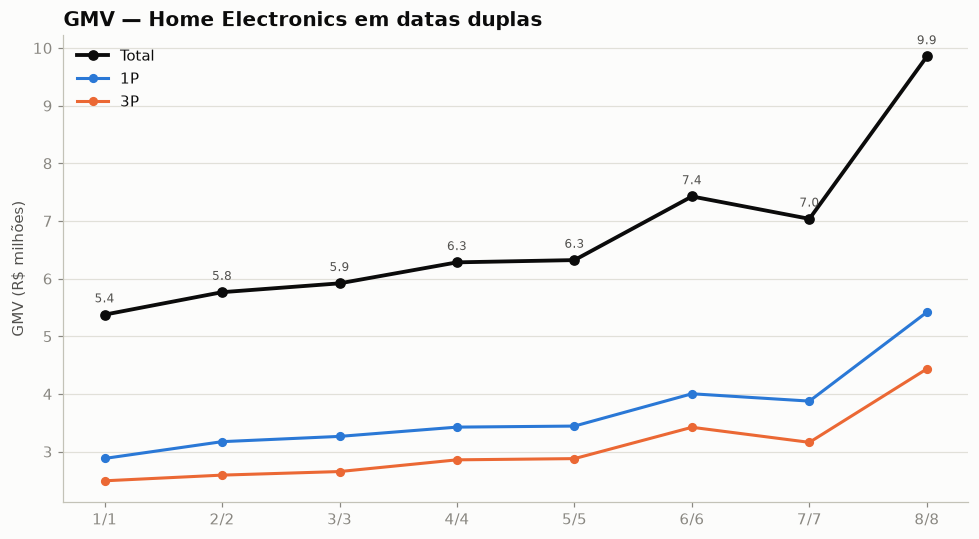

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(CHRONO_ORDER))

ax.plot(x, overall["gmv"] / 1e6, color=TEXT_PRIMARY, linewidth=2.5,
        marker="o", markersize=6, label="Total")
ax.plot(x, by_channel_gmv["1P"] / 1e6, color=COLOR_1P, linewidth=2,
        marker="o", markersize=5, label="1P")
ax.plot(x, by_channel_gmv["3P"] / 1e6, color=COLOR_3P, linewidth=2,
        marker="o", markersize=5, label="3P")

ax.set_xticks(list(x))
ax.set_xticklabels(CHRONO_ORDER)
ax.set_ylabel("GMV (R$ milhões)")
ax.set_title("GMV — Home Electronics em datas duplas", loc="left", fontweight="bold", fontsize=13)
ax.grid(axis="y", linewidth=0.8)
ax.legend(frameon=False, loc="upper left")

for xi, yi in zip(x, overall["gmv"] / 1e6):
    ax.annotate(f"{yi:,.1f}", (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig("chart1_gmv_trend.png", dpi=150)
plt.show()


## 8. Mix de canal (1P vs 3P) por data dupla

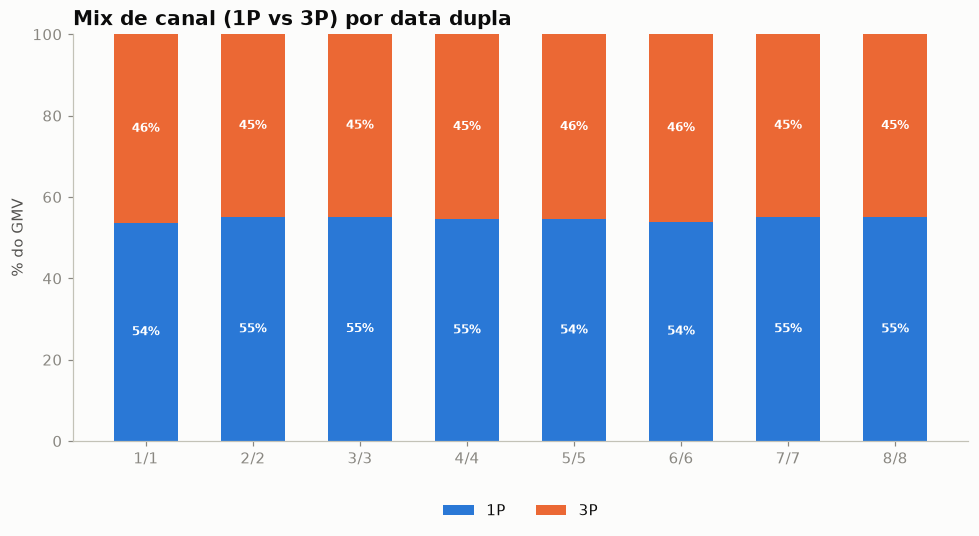

In [9]:
mix = by_channel_gmv.div(by_channel_gmv.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(CHRONO_ORDER))
for ch, color in [("1P", COLOR_1P), ("3P", COLOR_3P)]:
    vals = mix[ch].values
    ax.bar(CHRONO_ORDER, vals, bottom=bottom, color=color, label=ch, width=0.6)
    for xi, (b, v) in enumerate(zip(bottom, vals)):
        ax.annotate(f"{v:.0f}%", (xi, b + v / 2), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("% do GMV")
ax.set_ylim(0, 100)
ax.set_title("Mix de canal (1P vs 3P) por data dupla", loc="left", fontweight="bold", fontsize=13)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig("chart2_channel_mix.png", dpi=150)
plt.show()


## 9. GMV por categoria agg1 — 8/8 vs data dupla anterior

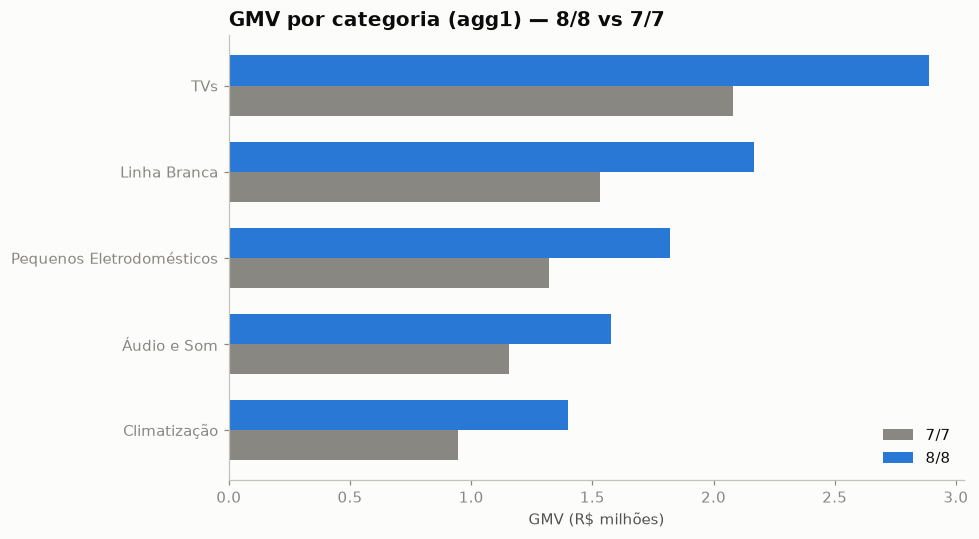

In [10]:
latest, previous = CHRONO_ORDER[-1], CHRONO_ORDER[-2]
comp = cat_gmv_pivot.loc[[previous, latest]].T / 1e6
comp = comp.sort_values(by=latest)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(comp))
h = 0.35
ax.barh(y - h / 2, comp[previous], height=h, color=TEXT_MUTED, label=previous)
ax.barh(y + h / 2, comp[latest], height=h, color=COLOR_1P, label=latest)
ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.set_xlabel("GMV (R$ milhões)")
ax.set_title(f"GMV por categoria (agg1) — {latest} vs {previous}", loc="left", fontweight="bold", fontsize=13)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("chart3_category_comparison.png", dpi=150)
plt.show()


## 10. Evolução do GMV por categoria agg1 em todas as datas duplas

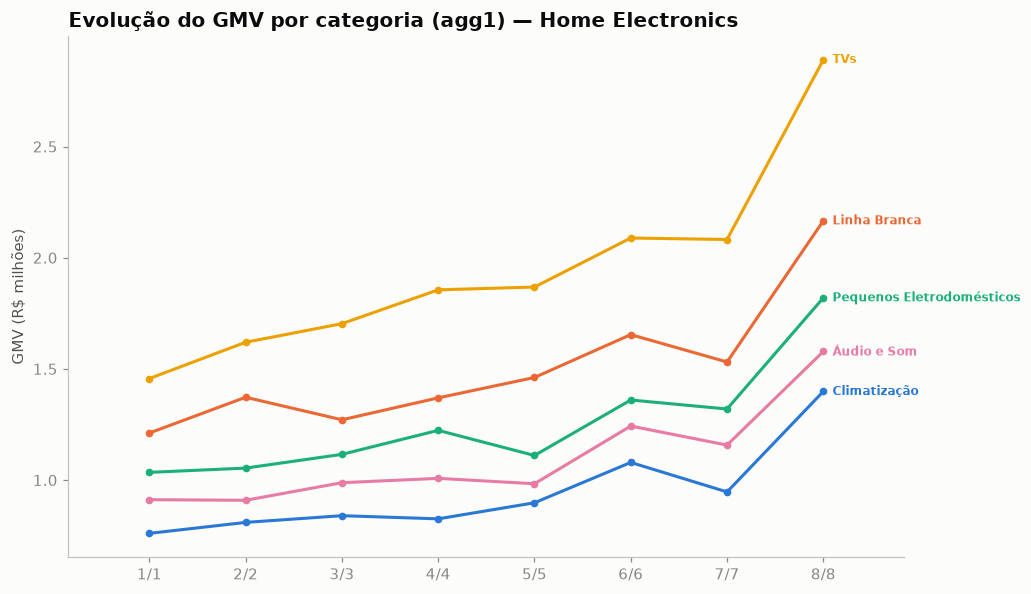

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for cat, color in zip(cat_gmv_pivot.columns, CAT_COLORS):
    series = cat_gmv_pivot[cat] / 1e6
    ax.plot(CHRONO_ORDER, series, color=color, marker="o", markersize=4, linewidth=2, label=cat)
    # rótulo direto no fim da linha (mitigação exigida p/ cores com baixo contraste)
    ax.annotate(cat, (len(CHRONO_ORDER) - 1, series.iloc[-1]), color=color,
                fontsize=8, fontweight="bold", xytext=(6, 0), textcoords="offset points",
                va="center")

ax.set_ylabel("GMV (R$ milhões)")
ax.set_title("Evolução do GMV por categoria (agg1) — Home Electronics", loc="left",
             fontweight="bold", fontsize=13)
ax.margins(x=0.12)

plt.tight_layout()
plt.savefig("chart4_category_trend.png", dpi=150)
plt.show()


## 11. Market share — Home Electronics

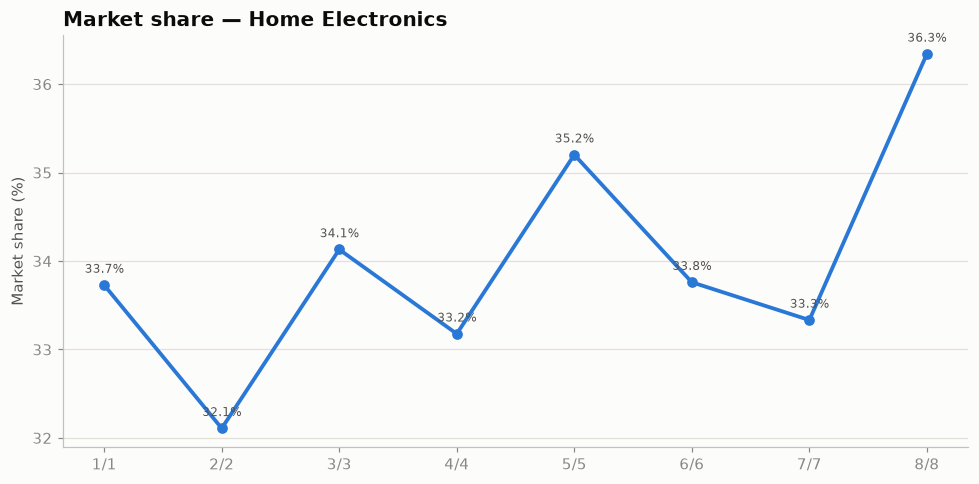

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
share_pct = overall["market_share"] * 100
ax.plot(CHRONO_ORDER, share_pct, color=COLOR_1P, marker="o", linewidth=2.5)
ax.set_ylabel("Market share (%)")
ax.set_title("Market share — Home Electronics", loc="left", fontweight="bold", fontsize=13)
ax.grid(axis="y", linewidth=0.8)

for xi, yi in enumerate(share_pct):
    ax.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig("chart5_market_share.png", dpi=150)
plt.show()


## 12. Tabela-resumo e export

In [13]:
summary = overall.copy()
summary["gmv_growth"] = summary["gmv_growth"] * 100
summary["units_growth"] = summary["units_growth"] * 100
summary["market_share"] = summary["market_share"] * 100

summary_display = summary.rename(columns={
    "gmv": "GMV (R$)",
    "units": "Unidades",
    "market_share": "Market Share (%)",
    "gmv_growth": "Δ GMV vs data dupla anterior (%)",
    "units_growth": "Δ Unidades vs data dupla anterior (%)",
})[["GMV (R$)", "Unidades", "Market Share (%)",
    "Δ GMV vs data dupla anterior (%)", "Δ Unidades vs data dupla anterior (%)"]]

summary_display.to_csv("resumo_datas_duplas_home_electronics.csv")
summary_display


,GMV (R$),Unidades,Market Share (%),Δ GMV vs data dupla anterior (%),Δ Unidades vs data dupla anterior (%)
date_label,,,,,
1/1,"5,375,085.71","8,411.62",33.73,NaN,NaN
2/2,"5,764,824.56","8,957.94",32.11,7.25,6.49
3/3,"5,918,166.39","9,182.01",34.13,2.66,2.50
4/4,"6,282,251.02","9,825.01",33.18,6.15,7.00
5/5,"6,321,416.57","9,820.41",35.20,0.62,-0.05
6/6,"7,425,197.58","11,315.77",33.76,17.46,15.23
7/7,"7,036,572.06","10,788.16",33.33,-5.23,-4.66
8/8,"9,852,564.90","15,340.62",36.34,40.02,42.20


## 13. Conclusões (preencher após rodar com dados reais)

- **GMV 8/8 vs 7/7:** _(ex.: cresceu X% impulsionado por categoria Y e canal Z)_
- **Canal:** _(1P ou 3P ganhou/perdeu participação? em quais categorias?)_
- **Categoria:** _(qual subcategoria de Home Electronics liderou o crescimento/queda?)_
- **Market share:** _(ganhamos ou perdemos share vs o mercado nesta data dupla?)_
- **Próximos passos:** _(ex.: investigar ruptura de estoque, efeito de campanha, comparar YoY)_
